# Set Up + Imports

In [105]:
from collections import OrderedDict
from typing import Optional
from typing import OrderedDict
from tqdm import tqdm
import sys
import json
import numpy as np
from numpy.random import Generator
from pydantic import BaseModel
from pydantic import ConfigDict
from pydantic import Field
import math
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import random

import networkx as nx
import enum

from torch.utils.data import Subset
from torch.utils.data import ConcatDataset
from torchvision import transforms
from torchvision import models
from torchvision.models import ResNet18_Weights # Import weights enum
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, random_split, Dataset
from torch.utils.data import DataLoader
import torch
import typing as t
T = t.TypeVar("T")
FloatTriple: t.TypeAlias = tuple[float, float, float]
from collections import defaultdict

from transformers import AutoTokenizer
from transformers import BertForSequenceClassification
from torch.optim import AdamW
from torch.optim import SGD
import torch.nn as nn
import torch.optim as optim


from wilds import get_dataset
from sklearn.metrics import f1_score, classification_report

# Data

## Tumor Classification

In [5]:
full_dataset = get_dataset(dataset="camelyon17", download=True)

class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        # Get the raw PIL image, label, and metadata from the subset
        x, y, metadata = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y, metadata

    def __len__(self):
        return len(self.subset)

# Use this in your get_manual_splits function
def get_manual_splits(dataset, train_ratio=0.2, transform=None):
    hospital_ids = dataset.metadata_array[:, 0]
    indices_0123 = torch.where(hospital_ids <= 3)[0]
    indices_4 = torch.where(hospital_ids == 4)[0]

    def split_indices(indices, ratio):
        train_size = int(len(indices) * ratio)
        return random_split(indices, [train_size, len(indices) - train_size])

    # Get the raw subsets
    raw_train_0123, raw_test_0123 = split_indices(indices_0123, train_ratio)
    raw_train_4, raw_test_4 = split_indices(indices_4, train_ratio)

    # Wrap them to apply the transform
    return (
        TransformedSubset(Subset(dataset, raw_train_0123), transform),
        TransformedSubset(Subset(dataset, raw_test_0123), transform),
        TransformedSubset(Subset(dataset, raw_train_4), transform),
        TransformedSubset(Subset(dataset, raw_test_4), transform)
    )

transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(), # This converts PIL -> Tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Create all 4 subsets
train_0123, test_0123, train_4, test_4 = get_manual_splits(full_dataset, transform=transform)

print(f"Hospitals 0-3 -> Train: {len(train_0123)}, Test: {len(test_0123)}")
print(f"Hospital 4    -> Train: {len(train_4)}, Test: {len(test_4)}")

# Define batch size
BATCH_SIZE = 256

train_loader_0123 = DataLoader(train_0123, batch_size=BATCH_SIZE, shuffle=True)
train_loader_4 = DataLoader(train_4, batch_size=BATCH_SIZE, shuffle=True)


test_loader_0123 = DataLoader(test_0123, batch_size=BATCH_SIZE, shuffle=False)
test_loader_4 = DataLoader(test_4, batch_size=BATCH_SIZE, shuffle=False)

Hospitals 0-3 -> Train: 61846, Test: 247386
Hospital 4    -> Train: 29344, Test: 117378


In [6]:
def resnet18_camelyon17(num_classes=2, use_pretrained=True):
    torch.manual_seed(2809)

    # Use ImageNet weights if use_pretrained is True
    weights = ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None
    m = models.resnet18(weights=weights)

    # Replace the final layer for the binary task
    m.fc = torch.nn.Linear(m.fc.in_features, num_classes)

    return m

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#model = TumorModule(num_classes=2).to(device)
model = resnet18_camelyon17(num_classes=2, use_pretrained=True).to(device)
optimizer = optim.SGD(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in tqdm(loader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Stats
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, name="Test Set"):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels, _ in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    accuracy = 100. * correct / total
    print(f"{name} Accuracy: {accuracy:.2f}%")
    return accuracy

num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader_0123, optimizer, criterion)
    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")

    # Evaluate on both test sets
    evaluate(model, test_loader_0123, name="Hospitals 0-3 (Seen)")
    evaluate(model, test_loader_4, name="Hospital 4 (Unseen)")
    print("-" * 30)


100%|██████████| 242/242 [01:24<00:00,  2.85it/s]


Epoch 1: Train Loss: 0.3996, Train Acc: 83.00%


KeyboardInterrupt: 

## Civil Comments

In [ ]:
# Load the full dataset (downloads if not exists)
dataset = get_dataset(dataset=DATASET_NAME, root_dir=ROOT_DIR, download=True)


SUBSET_SIZE = 3000


# Using range(SUBSET_SIZE) gets the first 1000 samples
train_data = Subset(dataset.get_subset("train"), range(SUBSET_SIZE))
val_data   = Subset(dataset.get_subset("val"),   range(SUBSET_SIZE))
test_data  = Subset(dataset.get_subset("test"),  range(SUBSET_SIZE))

In [ ]:


# Load a pre-trained tokenizer (e.g., BERT)
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
MAX_LENGTH = 512 # Or adjust as needed

def collate_fn_with_tokenizer(batch):
    # 'batch' is a list of (text, label, metadata) tuples from the dataset
    texts = [item[0] for item in batch]
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    metadata = torch.stack([item[2] for item in batch]) # Metadata can also be useful for group-wise evaluation

    # Tokenize and pad the texts
    encoded_texts = tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )
    return encoded_texts, labels, metadata

# Create DataLoaders
BATCH_SIZE = 16

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, collate_fn=collate_fn_with_tokenizer)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, collate_fn=collate_fn_with_tokenizer)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, collate_fn=collate_fn_with_tokenizer)


In [ ]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load a pre-trained BERT model for sequence classification
# The Civil Comments dataset is binary classification (toxic vs non-toxic)
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
model.to(device)

# Define loss function and optimizer
weights = torch.tensor([3.0, 1.0]).to(device) # Non-toxic is 3x rarer, so it gets 3x weight

# 2. Initialize the weighted loss function
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = AdamW(model.parameters(), lr=5e-5) # AdamW is a common optimizer for transformers

# Training loop (simplified)
NUM_EPOCHS = 1

for epoch in range(NUM_EPOCHS):
    model.train()
    for batch in tqdm(train_loader):
        inputs, labels, metadata = batch
        inputs = {k: v.to(device) for k, v in inputs.items()}
        labels = labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(**inputs, labels=labels)
        logits = outputs.logits

        loss = criterion(logits, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} finished. Loss: {loss.item():.4f}")

print("Finished Training")

In [ ]:
all_preds = []
all_labels = []
all_metadata = []

model.eval()
with torch.no_grad():
    for batch in test_loader:
        inputs, labels, metadata = batch
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=1)

        # Collect results back to CPU
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())
        all_metadata.append(metadata.cpu())

# Concatenate all batches into single tensors
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
all_metadata = torch.cat(all_metadata)

y_true = all_labels.numpy()
y_pred = all_preds.numpy()


print(f"F1-Score: {f1:.4f}")

# Comprehensive report including precision and recall
print(classification_report(y_true, y_pred, target_names=['Non-Toxic', 'Toxic']))

## Data Utils

In [51]:
def load_data(name="camelyon17", train:bool=True, iid:bool=True):
    if name == "camelyon17":
        class TransformedSubset(torch.utils.data.Dataset):
            def __init__(self, subset, transform=None):
                self.subset = subset
                self.transform = transform
        
            def __getitem__(self, index):
                # Get the raw PIL image, label, and metadata from the subset
                x, y, metadata = self.subset[index]
                if self.transform:
                    x = self.transform(x)
                return x, y #, metadata
        
            def __len__(self):
                return len(self.subset)
        
        # Use this in your get_manual_splits function
        def get_manual_splits(dataset, train_ratio=0.8, transform=None):
            hospital_ids = dataset.metadata_array[:, 0]
            indices_0123 = torch.where(hospital_ids <= 3)[0]
            indices_4 = torch.where(hospital_ids == 4)[0]
        
            def split_indices(indices, ratio):
                train_size = int(len(indices) * ratio)
                return random_split(indices, [train_size, len(indices) - train_size])
        
            # Get the raw subsets
            raw_train_0123, raw_test_0123 = split_indices(indices_0123, train_ratio)
            raw_train_4, raw_test_4 = split_indices(indices_4, train_ratio)
        
            # Wrap them to apply the transform
            return (
                TransformedSubset(Subset(dataset, raw_train_0123), transform),
                TransformedSubset(Subset(dataset, raw_test_0123), transform),
                TransformedSubset(Subset(dataset, raw_train_4), transform),
                TransformedSubset(Subset(dataset, raw_test_4), transform)
            )
        
        transform = transforms.Compose([
            transforms.Resize((96, 96)),
            transforms.ToTensor(), # This converts PIL -> Tensor
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        
        # Create all 4 subsets
        train_0123, test_0123, train_4, test_4 = get_manual_splits(full_dataset, transform=transform)

        if iid:
            if train:
                return train_0123
            else:
                return test_0123
        else:
            # OOD hospital 4 data
            if train:
                return train_4
            else:
                return test_4
        

In [52]:
def proportion_split(
    seq: t.Sequence[T],
    proportion: t.Sequence[float],
    rng_seed: int | None = None,
    labels: t.Sequence[T] = None,
) -> tuple[t.Sequence[T], ...]:
    """
    Split a sequence into multiple sequences based on proportions.

    Args:
        seq (Sequence[T]): Sequence to split.
        proportion (t.Sequence[float, ...]): Proportions to split the sequence.

    Returns:
        Sequences split based on the proportions. The number of sequences returned is
            equal to the length of the `proportion` argument.

    Examples:
        >>> lst = list(range(10))
        >>> lst
        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
        >>> proportion_split(lst, (0.5, 0.5))
        ([0, 1, 2, 3, 4], [5, 6, 7, 8, 9])
        >>> proportion_split(lst, (0.5, 0.2, 0.3))
        ([0, 1, 2, 3, 4], [5, 6], [7, 8, 9])

    Throws:
        - `ValueError`: If the number of proportions is greater than the number of
            values in the sequence.
        - `ValueError`: If the values in `proportion` argument are negative.
        - `ValueError`: If the values in `proportion` argument do not sum to 1.
    """
    if len(proportion) > 3:
        raise ValueError("Cannot make more than 3 splits (trian, test, val) ")
    if len(proportion) > len(seq):
        raise ValueError(
            "Number of proportions cannot be greater than the number of values in "
            "the sequence."
        )
    if any(p < 0 for p in proportion):
        raise ValueError("Proportions must be non-negative.")
    # if sum(proportion) != 1:
    # check if sum to 1, within a small tolerance for float arithmetic
    if not math.isclose(sum(proportion), 1):
        # print(sum(proportion))
        raise ValueError("Proportions must sum to 1.")

    # Need to ensure that test_size > # of classes
    num_classes = len(list(set(labels)))  # of classes

    test_size = int(len(seq) * proportion[-1])
    # print(f"{test_size=}")
    if test_size < num_classes:
        test_size = num_classes
    train, test, train_labels, test_labels = train_test_split(
        seq, labels, test_size=test_size, random_state=rng_seed, stratify=labels
    )
    if len(proportion) == 2:
        return (train, test)

    if len(proportion) == 3:
        # size of validation split
        test_size = int(len(train) * (proportion[1] / (proportion[0] + proportion[1])))
        if test_size < num_classes:
            test_size = num_classes
        train, val = train_test_split(
            train, test_size=test_size, random_state=rng_seed, stratify=train_labels
        )
        return (train, test, val)


def random_generator(
    rng: np.random.Generator | int | None = None,
) -> np.random.Generator:
    """
    Create a random number generator.

    Args:
        rng (numpy.random.Generator | int | None): Random number generator.

    Returns:
        Random number generator.

    Notes:
        What is returned by this function depends on what is given to the `rng` arg:

        1. If `rng` is a `numpy.random.Generator`, it is returned as is.
        2. If `rng` is an integer, it is used to seed the random number generator.
        3. If `rng` is `None`, then a pseudorandom  random number generator is
            returned using `numpy.random.default_rng(None)`.

    Throws:
        - `ValueError`: Is thrown if an illegal value type is passed in as an argument.
    """
    match rng:
        case np.random.Generator():
            return rng
        case int() | None:
            return np.random.default_rng(rng)
        case _:
            raise ValueError(
                f"Illegal value type for arg `rng`; expected a "
                f"`numpy.random.Generator`, int, or `None`, got "
                f"{type(rng)}."
            )


def federated_split(
    ckpt_dir: str,
    num_workers: int,
    data: Dataset,
    num_labels: int,
    label_alpha: float,
    sample_alpha: float,
    train_test_valid_split: FloatTriple | None = None,
    ensure_at_least_one_sample: bool = True,
    rng: np.random.Generator | int | None = None,
    allow_overlapping_samples: bool = False,
) -> tuple[dict[int, list[int]], dict[int, list[int]], dict[int, list[int]]]:
    """
    Splits a dataset across a federation of workers.

    The splitting of a dataset can be tuned via the `label_alpha` and `sample_alpha`
    arguments to simulate iid and non-iid data distributions across workers in
    a federation.

    Args:
        topo (Topology): The topology of the federation.
        data (Data): The dataset to split across workers.
        num_labels (int): The number of labels/classes in the dataset. This, of course,
            must be at least 1.
        label_alpha (float): The concentration parameter across labels for the
            Dirichlet distribution.
        sample_alpha (float): The concentration parameter across samples for the
            Dirichlet distribution.
        train_test_valid_split (FloatTriple | FloatDouble | None): The split ratio
            for the training, testing, and validation datasets.
        ensure_at_least_one_sample (bool): If `True`, this ensures that each worker
            has at least 1 data sample; `False` if you want no such guarantee. It is
            generally encouraged to ensure at least 1 sample per worker.
        rng (numpy.random.Generator | int | None): Random number generator.
        allow_overlapping_samples (bool): If `True`, this allows for samples that can
            be shared across workers; `False` if you want no such sharing.

    Returns:
        A federated data module that where the originally provided dataset is now split
            across the workers following a Dirichlet distribution along classes and
            samples.

    """
    data_path_name = f"{ckpt_dir}/{num_workers}_fed_split.pt"
    os.makedirs(os.path.dirname(data_path_name), exist_ok=True)

    if os.path.isfile(data_path_name):
        print("loading federated split data: ", data_path_name)
        data = torch.load(
            data_path_name, map_location=torch.device("cpu"), weights_only=False
        )
        train_indices = data["train_indices"]
        test_indices = data["test_indices"]
        valid_indices = data["valid_indices"]
        return (train_indices, test_indices, valid_indices)

    if label_alpha <= 0 or sample_alpha <= 0:
        raise ValueError(
            "Both `label_alpha` and `sample_alpha` must be greater than 0."
        )
    if num_labels < 1:
        raise ValueError("The number of labels must be at least 1.")

    try:
        train_data_len = len(data)  # type: ignore
    except NotImplementedError as err:
        err.add_note("The provided dataset must have `__len__()` implemented.")
        raise err

    generator = random_generator(rng)
    # num_workers = topo.number_of_nodes(NodeKind.WORKER)
    sample_distr = generator.dirichlet(np.full(num_workers, sample_alpha))
    label_distr = generator.dirichlet(
        np.full(num_labels, label_alpha), size=num_workers
    )
    num_samples = (sample_distr * train_data_len).astype(int)

    label_probs_per_worker = {}
    samples_per_worker = {}
    for worker, label_prob, samples in zip(
        range(num_workers), label_distr, num_samples
    ):
        label_probs_per_worker[worker] = label_prob
        samples_per_worker[worker] = samples

    indices: dict[int, list[int]] = defaultdict(list)  # indices on each worker
    indices_labels: dict[int, list[int]] = defaultdict(list)  # labels on each worker
    worker_samples: dict[int, int] = defaultdict(int)  # num. samples on each worker

    labels = []
    for idx, batch in enumerate(tqdm(DataLoader(data, batch_size=1))):
        _, label = batch
        label = label.item()
        labels.append(label)

        probs, temp_workers = [], []
        for w in range(num_workers):
            if worker_samples[w] < samples_per_worker[w]:
                try:
                    # print(f"{w=}, {label=}")
                    probs.append(label_probs_per_worker[w][label])
                    temp_workers.append(w)
                except IndexError as err:
                    if isinstance(label, float):
                        err.add_note(
                            "Label cannot be of type `float` (must be an `int`). "
                            "Perhaps, use `y.to(torch.int32)` in your `Dataset` object "
                            "definition to resolve this issue."
                        )
                    raise err

        probs_norm = np.array(probs)
        probs_norm = probs_norm / probs_norm.sum()

        if len(temp_workers) > 0:
            chosen_worker = generator.choice(temp_workers, p=probs_norm)
            indices[chosen_worker].append(idx)
            indices_labels[chosen_worker].append(labels[idx])
            worker_samples[chosen_worker] += 1

    num_classes = len(list(set(labels)))  # of classes
    if ensure_at_least_one_sample:
        # if ensure_at_least_one_sample and train_test_valid_split is not None:
        # Add one sample for each split
        num_splits = 1
        if train_test_valid_split != None:
            num_splits = len(train_test_valid_split)
        for i in range(num_splits):
            print("Adding data to split w/ least data")
            for worker in range(num_workers):
                worker_with_most_samples = max(worker_samples, key=worker_samples.get)
                if worker_samples[worker] == 0 + i:
                    index = indices[worker_with_most_samples].pop()
                    label = indices_labels[worker_with_most_samples].pop()
                    worker_samples[worker_with_most_samples] -= 1

                    indices[worker].append(index)
                    indices_labels[worker].append(label)
                    worker_samples[worker] += 1

    # For stratifying purposes, need at least 1 instance of every label per # of splits
    # if we have (train, test) then we need 2 instances of every label
    # if we have (train, test, val) we need 3 instances of every label
    if train_test_valid_split is not None:
        min_count = len(train_test_valid_split)
        for worker in range(num_workers):
            worker_with_most_samples = max(worker_samples, key=worker_samples.get)
            # print(f"{worker=}")
            for i in range(num_classes):
                while indices_labels[worker].count(i) < min_count:
                    label_idx = indices_labels[worker_with_most_samples].index(i)

                    index = indices[worker_with_most_samples].pop(label_idx)
                    label = indices_labels[worker_with_most_samples].pop(label_idx)
                    worker_samples[worker_with_most_samples] -= 1

                    indices[worker].append(index)
                    indices_labels[worker].append(label)
                    worker_samples[worker] += 1
                # print(f"class={i}, count={indices_labels[worker].count(i)}")

    # print(f"{len(indices[0])=}, {len(indices_labels[0])=}")
    rng_seed = generator.integers(low=0, high=4294967295, size=1).item()
    if train_test_valid_split is None:
        train_indices = indices
        test_indices = None
        valid_indices = None

    elif len(train_test_valid_split) == 2:
        train_indices, test_indices = dict(), dict()
        valid_indices = None
        for w_idx, w_indices in indices.items():
            train_split, test_split = proportion_split(
                w_indices, train_test_valid_split, rng_seed, indices_labels[w_idx]
            )
            train_indices[w_idx] = train_split
            test_indices[w_idx] = test_split

    elif len(train_test_valid_split) == 3:
        train_indices, test_indices, valid_indices = dict(), dict(), dict()
        for w_idx, w_indices in indices.items():
            train_split, test_split, valid_split = proportion_split(
                w_indices,
                train_test_valid_split,
                rng_seed,
                indices_labels[w_idx],
            )
            train_indices[w_idx] = train_split
            test_indices[w_idx] = test_split
            valid_indices[w_idx] = valid_split

    else:
        raise ValueError("Invalid number of elements in `train_test_valid_split`.")

    for idx, indices in train_indices.items():
        print(f"{idx=}, {len(indices)=}")

    torch.save(
        {
            "train_indices": train_indices,
            "test_indices": test_indices,
            "valid_indices": valid_indices,
        },
        data_path_name,
    )

    return (train_indices, test_indices, valid_indices)

In [57]:
tumor_data = load_data(name="camelyon17", train=True, iid=True)
print("loaded data")
client_ids = [0,1,2,3,4,5,6,7,8,9]
(train_indices, test_indices, valid_indices) = federated_split(
    ckpt_dir = "tumor_data_ckpt.pth",
    num_workers = len(client_ids),
    data = tumor_data,
    num_labels = 2,
    label_alpha = 1000,
    sample_alpha = 1000,
    train_test_valid_split= (0.7, 0.2, 0.1),
    ensure_at_least_one_sample = True,
    rng = 1,
    allow_overlapping_samples = False,
) 

loaded data
loading federated split data:  tumor_data_ckpt.pth/fed_split.pt


100%|██████████| 16919/16919 [00:18<00:00, 899.46it/s]


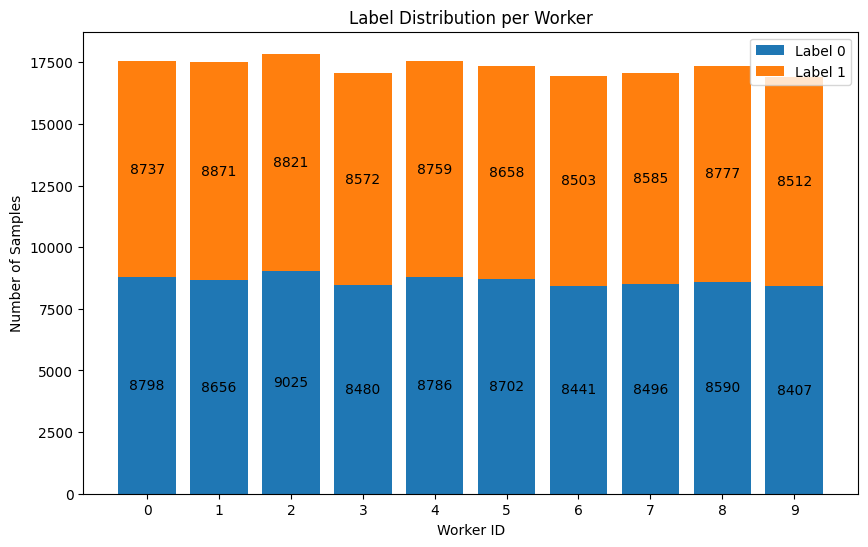

In [66]:
# Visualize the label distribution

def get_label_counts(
    num_clients: int,
    num_labels: int,
    subsets: dict[int, Subset],
) -> dict[
    int, list[int]
]:  # return dict of lists (each key is a label), list is the length of # of clients
    """return label count dict for each data split"""

    # save label counts per worker
    label_counts_per_worker = {label: [0] * num_clients for label in range(num_labels)}

    for idx in range(num_clients):
        for batch in tqdm(subsets[idx]):
            _, label = batch
            label_counts_per_worker[label.item()][idx] += 1

    return label_counts_per_worker

train_subsets = {idx: Subset(tumor_data, train_indices[idx]) for idx in client_ids}
label_counts_per_worker = get_label_counts(num_clients=len(client_ids), num_labels = 2, subsets = train_subsets)

worker_ids = [str(i) for i in range(len(client_ids))]
labels = sorted(label_counts_per_worker.keys())

fig, ax = plt.subplots(figsize=(10, 6))

# Initialize the bottom of the stacks at zero
bottom = np.zeros(len(worker_ids))

for label in labels:
    counts = label_counts_per_worker[label]
    # Plot the bar for the current label on top of the 'bottom'
    p = ax.bar(worker_ids, counts, bottom=bottom, label=f'Label {label}')
    
    # Update the bottom for the next label layer
    bottom += counts
    
    # Optional: add count labels inside segments
    ax.bar_label(p, label_type='center')

ax.set_xlabel('Worker ID')
ax.set_ylabel('Number of Samples')
ax.set_title('Label Distribution per Worker')
ax.legend()

plt.show()

# Topology + Placement Info

In [68]:
def get_placement_locations_by_top_n_degree(g, n=3):
    deg_cent = nx.degree_centrality(g)
    print(f"Getting degree based placement: {len(g)=}, {n=}")

    start = 0
    interval = len(g) // n

    degrees = torch.tensor(list(deg_cent.values()))
    val, ind = torch.sort(degrees, descending=True)

    l = list(range(0, n))

    placement_neighbors = torch.index_select(ind, 0, torch.tensor(l))
    return placement_neighbors.tolist()

def mk_ba_topos(
    num_nodes=4, seed=0,
) -> tuple[list[str], list[list[int]]]:
    # return (paths of topo file names, nodes to test per topo)
    # placement type == "multi" or single
    topo_dir = "topology"
    os.makedirs(topo_dir, exist_ok=True)

    # graphs = []
    graphs = {}

    # BA
    for n in [
        33,
    ]:
        for m in [3]:  # 1, 2
            g = nx.barabasi_albert_graph(n=n, m=m, seed=seed)
            graphs[f"barabasi_albert_{n}_{m}_{seed}"] = g

    paths = []
    nodes = []
    idx = 0
    for graph_name, G in graphs.items():

        
        degree_placement_nodes = get_placement_locations_by_top_n_degree(G, num_nodes)
        ood_placement_nodes = []
        for ood_node in degree_placement_nodes:
            ood_placement_nodes.append( [ood_node,])

        topology = nx.to_numpy_array(G)
        path = f"{topo_dir}/topo_{graph_name}.txt"
        np.savetxt(path, topology, fmt="%d")
        paths.append(path)
        nodes.append(
            ood_placement_nodes
            # [
            #    0,
            # ]
        )  # these are the list of nodes for each graph that need to be backdoored
        idx += 1

    return paths, nodes

topo_paths, ood_nodes = mk_ba_topos()

Getting degree based placement: len(g)=33, n=4


In [69]:
topo_paths

['topology/topo_barabasi_albert_33_3_0.txt']

In [71]:
ood_nodes[0] # for the 1st (and only) topo...place ood data on node 0, then node 4, .... (for multi node placements each inner-most list would need multiple nodes)

[[0], [4], [5], [1]]

In [90]:
def create_centrality_dict(
    topology: np.array,  # list[list[int]],
    rng: Generator,
) -> dict[str, dict[int, float]]:
    print("Creating centrality dict")
    # convert np array to graph
    G = nx.from_numpy_array(topology)

    centrality_dict = {}
    for centrality_type in ["degree", "betweenness", "random", "closeness", "eigen"]:
        if centrality_type == "degree":
            cent = nx.degree_centrality(G)
        if centrality_type == "betweenness":
            cent = nx.betweenness_centrality(G, normalized=True, endpoints=True)
        if centrality_type == "closeness":
            cent = nx.closeness_centrality(G)
        if centrality_type == "eigen":
            cent = nx.eigenvector_centrality_numpy(G)
        """
        if centrality_type == "cluster":
            cent = nx.degree_centrality(G)
        """
        if centrality_type == "random":
            # generator = random_generator(rng)
            # random_list = generator.dirichlet(np.ones(len(G)))
            # random_list = np.random.dirichlet(np.ones(len(G)), size=1).squeeze()
            # random_list =
            random_coeffs = rng.uniform(low=0.0, high=1.0, size=len(G))
            cent = {}
            for i in range(len(G)):
                cent[i] = random_coeffs[i].item()
            print(f"{cent=}")

        centrality_dict[centrality_type] = cent

    # This function returns a dict of different types of centrality dicts
    return centrality_dict

# Models

In [110]:
def create_model(data_name:str):

    if "camelyon17" == data_name:
        def resnet18_camelyon17(num_classes=2, use_pretrained=True):
            torch.manual_seed(2809)
        
            # Use ImageNet weights if use_pretrained is True
            weights = ResNet18_Weights.IMAGENET1K_V1 if use_pretrained else None
            m = models.resnet18(weights=weights)
        
            # Replace the final layer for the binary task
            m.fc = torch.nn.Linear(m.fc.in_features, num_classes)
        
            return m
    
        return resnet18_camelyon17(num_classes=2, use_pretrained=True).to(device)

# Clients

In [117]:
class DecentralClient(BaseModel):
    """Client class."""

    model_config = ConfigDict(arbitrary_types_allowed=True)

    idx: int = Field(description="Client ID.")
    model: torch.nn.Module = Field(description="Client local model.")
    train_data: Optional[Subset] = Field(  # noqa: UP007
        description="Subset of data this client will train on.",
    )
    test_data: Optional[Subset] = Field(  # noqa: UP007
        description="Subset of local data this client will test on.",
    )
    valid_data: Optional[Subset] = Field(  # noqa: UP007
        description="Subset of local data this client will validate on.",
    )
    global_test_data: Dataset = Field(
        description="global set of test data that every client and global model is evaluated on."
    )
    global_ood_test_data: Optional[Subset] = Field(  # noqa: UP007
        description="Subset of global test data that has been ooded (for testing ASR).",
    )
    neighbors: list[int] = Field(description="list of this clients neighbors")
    neighbor_probs: list[float] = Field(
        description="list of this clients neighbors' network connection probabilities (for modeling faulty networks)"
    )
    # NOTE(MS): currenlty we maintain a glocal view of the centrlaity metrics in the main app,
    # NOTE (MS): maybe in the future it may make sense for each node to have a local view of the topology centrality measures
    # centrality_dict: dict[str, dict[int, float]] = Field(
    #    description="Dict to track node-wise centrality metrics"
    # )

    def get_neighbors(self) -> list[int]:
        neighbor_idxs = self.neighbors
        neighbor_probs = self.neighbor_probs
        # This is where we set the probability of including a speicfic neighbor in that aggregation round
        # simulating faulty networks
        prob_idxs = np.random.binomial(1, neighbor_probs)
        # mask out any neighbors that don't make the inclusion threshold
        neighbor_idxs = [a for a, b in zip(neighbor_idxs, prob_idxs) if b > 0]
        return neighbor_idxs

def create_clients(
    num_clients: int,
    data_name: str,
    # train: bool,
    train_data: Dataset,
    num_labels: int,
    global_test_data: Dataset,
    label_alpha: float,
    sample_alpha: float,
    rng: Generator,
    topology: np.array,  # list[list[int]],
    train_test_val_split: tuple[float],
    ood_test_data: Dataset,
    ood_type: bool,
    ood_proportion: float,
    ood_node_idxs: list[int],
    random_bd: bool = False,
    # many-to-many or many-to-one backdoor from https://arxiv.org/pdf/1708.06733
    many_to_one: bool = True,
    offset_clients_data_placement: int = 0,  # this is how many clients we off set the data assignment by
    centrality_metric_data_placement: str = "degree",
    random_data_placement: bool = True,
    ckpt_dir: str = "./ckpt",
    trigger: int = 100,
) -> list[DecentralClient]:
    """Create many clients with disjoint sets of data.

    Args:
        num_clients: Number of clients to create.
        data_name: The name of the data used. Used for initializing the
            corresponding model.
        train: If the application is using the no-op training task, then this
            function skips the step for giving each client their own subset
            of data.
        train_data: The original dataset that will be split across the clients.
        global_test_data: The global test dataset that each client will be assessed on.
        data_alpha: The
            [Dirichlet](https://en.wikipedia.org/wiki/Dirichlet_distribution)
            distribution alpha value for the number of samples across clients.
        rng: Random number generator.

    Returns:
        List of clients.
    """
    client_ids = list(range(num_clients))

    client_indices: dict[int, list[int]] = {idx: [] for idx in client_ids}

    # TODO(MS) to create balanced local train and test sets
    # TODO(MS): pass in train_test_valid_split
    (train_indices, test_indices, valid_indices) = federated_split(
        ckpt_dir=ckpt_dir,
        # data_name=data_name,
        num_workers=num_clients,
        data=train_data,
        num_labels=num_labels,
        label_alpha=label_alpha,
        sample_alpha=sample_alpha,
        # train_test_valid_split=None,
        train_test_valid_split=train_test_val_split,
        # train_test_valid_split=(0.7, 0.2, 0.1),
        ensure_at_least_one_sample=True,
        rng=rng,
        allow_overlapping_samples=False,
    )
    # print(f"{len(train_indices[0])=}")

    centrality_dict = create_centrality_dict(topology, rng=rng)
    test_subsets = {idx: None for idx in range(num_clients)}
    valid_subsets = {idx: None for idx in range(num_clients)}
    train_subsets = {idx: Subset(train_data, train_indices[idx]) for idx in client_ids}
    if test_indices is not None:
        test_subsets = {idx: Subset(train_data, test_indices[idx]) for idx in client_ids}
    if valid_indices is not None:
        valid_subsets = {
            idx: Subset(train_data, valid_indices[idx]) for idx in client_ids
        }

    if ood_type:
        rng_seed = rng.integers(low=0, high=4294967295, size=1).item()
        for ood_node_idx in ood_node_idxs:
            stratify_targets = [label for x, label in train_subsets[ood_node_idx]]
            clean_data, bd_data = ood_data(
                data_name,
                train_subsets[ood_node_idx],
                stratify_targets,
                ood_proportion,
                rng_seed,
                rng,
                num_labels,
                random_bd,
                many_to_one,
                trigger=trigger,
                ood_type=ood_type,
            )
            # combine clean + bd training data
            concat_data = ConcatDataset([clean_data, bd_data])
            clean_len = len(clean_data)
            bd_len = len(bd_data)
            new_indices = list(range(clean_len + bd_len))
            # new_indices = list(range(len(stratify_targets)))
            # wrap new bd-ed data in Subset class
            train_subsets[ood_node_idx] = Subset(concat_data, new_indices)
            print(f"ooded client {ood_node_idx} data")

    clients = []
    for idx in client_ids:
        neighbors = np.where(topology[idx] > 0)[0].tolist()
        prob_idxs = np.argwhere(topology[idx] > 0)
        probs = (topology[idx][prob_idxs]).flatten().tolist()
        print(f"client: {idx}, neighbors: {neighbors}, neighbor probabilities: {probs}")
        # print(f"train data size: {len(train_subsets[idx])}")
        client = DecentralClient(
            idx=idx,
            model=create_model(data_name),
            train_data=train_subsets[idx],
            test_data=test_subsets[idx],
            valid_data=valid_subsets[idx],
            global_test_data=global_test_data,
            neighbors=neighbors,
            neighbor_probs=probs,
            global_ood_test_data=ood_test_data,
            # centrality_dict=centrality_dict,
        )
        clients.append(client)

    return clients

def ood_data(
    data_name: str,
    data: Dataset,
    stratify_targets: list[int],  # the labels to preserve class proportion in the split
    proportion_backdoor: float = 0.1,  # proportion of data that should be backdoored
    rng_seed: int | None = None,  # set rng seed
    rng: np.random.Generator | int | None = None,
    num_labels: int = 10,
    random: bool = False,
    # many-to-many or many-to-one backdoor from https://arxiv.org/pdf/1708.06733
    many_to_one: bool = True,
    # for propoer checkpointing purposes we need to save some additional info
    offset_clients_data_placement: int = 0,
    centrality_metric_data_placement: str = "degree",
    # random_data_placement: bool = True,
    # backdoor_node_idx: int = 0,
    # num_clients: int = 0,
    # test_data: int = 0,
    trigger: int = 100,
    ood_type: str = "bd",
) -> (Dataset, Dataset):
    # print(data)
    print("+++++++++Converting to OOD data.++++++++++")
    # data_path_name = f"data/{data_name}_{proportion_backdoor}_{rng_seed}_{rng}_{random}_{many_to_one}_{offset_clients_data_placement}_{random_data_placement}_{backdoor_node_idx}_{num_clients}_{test_data}_backdoor.pt"
    # os.makedirs(os.path.dirname(data_path_name), exist_ok=True)

    indices = list(range(len(data)))
    try:
        clean_indices, backdoor_indices = train_test_split(
            indices,
            test_size=proportion_backdoor,
            random_state=rng_seed,
            stratify=stratify_targets,
        )
    except:
        clean_indices, backdoor_indices = train_test_split(
            indices,
            test_size=proportion_backdoor,
            random_state=rng_seed,
            # stratify=stratify_targets,
        )

    clean_data = Subset(data, clean_indices)
    num_backdoor_data = len(backdoor_indices)
    
    tumor_data_train_ood = load_data(name="camelyon17", train=True, iid=False)

    #randomly grab a subset of ood hospital indices
    ood_indices = np.random.choice(len(tumor_data_train_ood), size = num_backdoor_data, replace=False)
                                  
    ood_data = Subset(tumor_data_train_ood, ood_indices)   

    return clean_data, ood_data  # make this data, backdoor data

In [120]:
topology = np.loadtxt(topo_paths[0], dtype=float)
tumor_data_train = load_data(name="camelyon17", train=True, iid=True)
tumor_data_test = load_data(name="camelyon17", train=False, iid=True)
tumor_data_test_ood = load_data(name="camelyon17", train=False, iid=False)
tumor_data_test_ood = Subset(tumor_data_test_ood, range(len(tumor_data_test_ood)))
rng = np.random.default_rng(0)

clients = create_clients(
    num_clients = len(topology),
    data_name = "camelyon17",
    # train: bool,
    train_data = tumor_data_train,
    num_labels = 2,
    global_test_data = tumor_data_test,
    label_alpha = 1000,
    sample_alpha = 1000,
    rng=rng,
    topology=topology,
    train_test_val_split=(0.8, 0.2), # local train and test
    ood_test_data = tumor_data_test_ood, # global ood test data
    ood_type = "hospital",
    ood_proportion = 0.1,
    ood_node_idxs = ood_nodes[0][0],
    random_bd = False,
    # many-to-many or many-to-one backdoor from https://arxiv.org/pdf/1708.06733
    many_to_one= False,
    offset_clients_data_placement = 0,  # this is how many clients we off set the data assignment by
    centrality_metric_data_placement = "degree",
    random_data_placement = True,
    ckpt_dir = "./ckpt",
    trigger = 100,
)

loading federated split data:  ./ckpt/fed_split.pt
Creating centrality dict
cent={0: 0.6369616873214543, 1: 0.2697867137638703, 2: 0.04097352393619469, 3: 0.016527635528529094, 4: 0.8132702392002724, 5: 0.9127555772777217, 6: 0.6066357757671799, 7: 0.7294965609839984, 8: 0.5436249914654229, 9: 0.9350724237877682, 10: 0.8158535541215322, 11: 0.002738500170148095, 12: 0.8574042765875693, 13: 0.033585575305464355, 14: 0.7296554464299441, 15: 0.17565562060255901, 16: 0.8631789223498866, 17: 0.5414612202490917, 18: 0.2997118905373848, 19: 0.42268722119765845, 20: 0.028319671145462966, 21: 0.12428327649956394, 22: 0.6706244146936303, 23: 0.6471895115742501, 24: 0.6153851114812539, 25: 0.38367755426188344, 26: 0.997209935789211, 27: 0.9808353387762301, 28: 0.6855419844806947, 29: 0.6504592762678163, 30: 0.6884467305709401, 31: 0.3889214239791038, 32: 0.13509650502241122}
+++++++++Converting to OOD data.++++++++++
ooded client 0 data
client: 0, neighbors: [1, 2, 3, 4, 5, 6, 10, 12, 15, 16, 17,

# Train/Test Utils

# Aggregation Strategies

# Decentralized Learning Application